**6. Stateful computations**

JAX transformations like `jit(), vmap(), grad()`, require the functions they wrap to be pure: that is, functions whose outputs depend solely on the inputs, and which have no side effects such as updating of global state.

This constraint can pose some challenges in the context of machine learning, where state may exist in many forms. For example:

* Model parameters,
* Optimizer state, and
* Stateful layers.


**Simple example: Counter**



In [1]:
import jax
import jax.numpy as jnp

class Counter:
  """A simple counter."""

  def __init__(self):
    self.n = 0

  def count(self) -> int:
    """Increments the counter and returns the new value."""
    self.n += 1
    return self.n

  def reset(self):
    """Resets the counter to zero."""
    self.n = 0


counter = Counter()

for _ in range(3):
  print(counter.count())

1
2
3


self.n is the state that is maintained and modified as a side-effect during count() calls.

For the sake of example, assume we must JIT compile count() to improve performance.

In [2]:
counter.reset()
fast_count = jax.jit(counter.count)

for _ in range(3):
  print(fast_count())

1
1
1


Our counter isn’t working. This is because the line `self.n += 1` in count involves a side effect: it modifies the input counter in-place, and so this function is not supported by jit. Such side effects are executed only once when the function is first traced, and subsequent calls will not repeat the side effect.

**The solution: explicit state**

Allow the user to manage the necessary state so that count() can be pure and therefore JIT compiled.

In [3]:
CounterState = int


class Counter:
    """A simple counter."""

    def count(self, n: CounterState) -> int:
        return n + 1

    def reset(self):
        return 0


c = Counter()
state = c.reset()

fast_count = jax.jit(c.count)

for _ in range(3):
    state = fast_count(state)
    print(state)

1
2
3


**Linear Regression Example**

Consider an example of a linear regression via gradient descent. Here, the only state is model parameters: The function to look at carefully is `update`.


In [4]:
from typing import NamedTuple

class Params(NamedTuple):
  weight: jnp.ndarray
  bias: jnp.ndarray


def init(rng) -> Params:
  """Returns the initial model params."""
  weights_key, bias_key = jax.random.split(rng)
  weight = jax.random.normal(weights_key, ())
  bias = jax.random.normal(bias_key, ())
  return Params(weight, bias)


def loss(params: Params, x: jnp.ndarray, y: jnp.ndarray) -> jnp.ndarray:
  """Computes the least squares error of the model's predictions on x against y."""
  pred = params.weight * x + params.bias
  return jnp.mean((pred - y) ** 2)


LEARNING_RATE = 0.005

@jax.jit
def update(params: Params, x: jnp.ndarray, y: jnp.ndarray) -> Params:
  """Performs one SGD update step on params using the given data."""
  grad = jax.grad(loss)(params, x, y)

  # If we were using Adam or another stateful optimizer,
  # we would also do something like
  #
  #   updates, new_optimizer_state = optimizer(grad, optimizer_state)
  #
  # and then use `updates` instead of `grad` to actually update the params.
  # (And we'd include `new_optimizer_state` in the output, naturally.)

  new_params = jax.tree.map(
      lambda param, g: param - g * LEARNING_RATE, params, grad)

  return new_params

Notice that we manually pipe the params in and out of the update function.

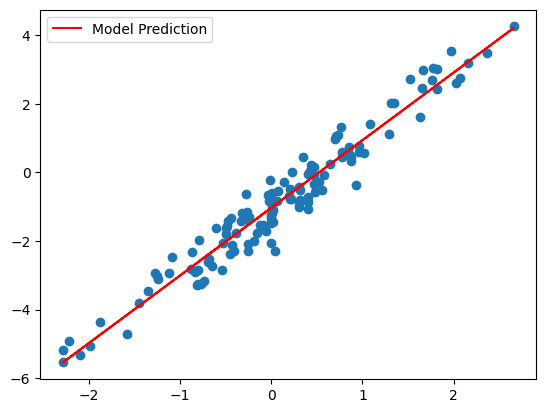

In [5]:
import matplotlib.pyplot as plt

rng = jax.random.key(42)

# Generate true data from y = w*x + b + noise
true_w, true_b = 2, -1
x_rng, noise_rng = jax.random.split(rng)
xs = jax.random.normal(x_rng, (128, 1))
noise = jax.random.normal(noise_rng, (128, 1)) * 0.5
ys = xs * true_w + true_b + noise

# Fit regression
params = init(rng)
for _ in range(1000):
  params = update(params, xs, ys)

plt.scatter(xs, ys)
plt.plot(xs, params.weight * xs + params.bias, c='red', label='Model Prediction')
plt.legend();

In [8]:
from typing import NamedTuple

LEARNING_RATE = 0.005


class Params(NamedTuple):
    weights: jnp.ndarray
    biases: jnp.ndarray


def init(rng):
    """Initialize model weights and biases randomly"""
    W_key, b_key = jax.random.split(rng, 2)
    W = jax.random.normal(W_key, ())
    b = jax.random.normal(b_key, ())
    return Params(W, b)


def loss(params, x, y):
    """Compute the MSE of the model's prediction on x against y"""
    preds = params.weights * x + params.biases
    return jnp.mean((preds - y) ** 2)


@jax.jit
def update(params, x, y):
    loss_value, grads = jax.value_and_grad(loss)(params, x, y)

    # Adjust weights by gradient direction amplified by learning rate
    return loss_value, jax.tree.map(lambda param, g: param - g * LEARNING_RATE, params, grads)

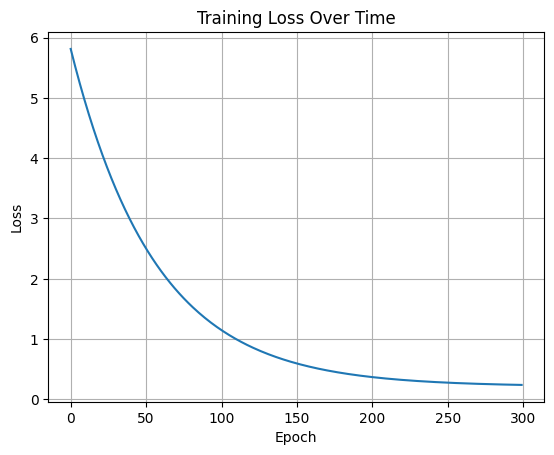

In [9]:
import matplotlib.pyplot as plt

rng = jax.random.key(42)

# Generate true data from y = w*x + b + noise
true_w, true_b = 2, -1
x_rng, noise_rng = jax.random.split(rng)
xs = jax.random.normal(x_rng, (128, 1))
noise = jax.random.normal(noise_rng, (128, 1)) * 0.5
ys = xs * true_w + true_b + noise

# Fit regression
params = init(rng)
losses = []
for i in range(300):
    loss_value, params = update(params, xs, ys)
    losses.append(loss_value)

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.grid(True)
plt.show()